In [2]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)


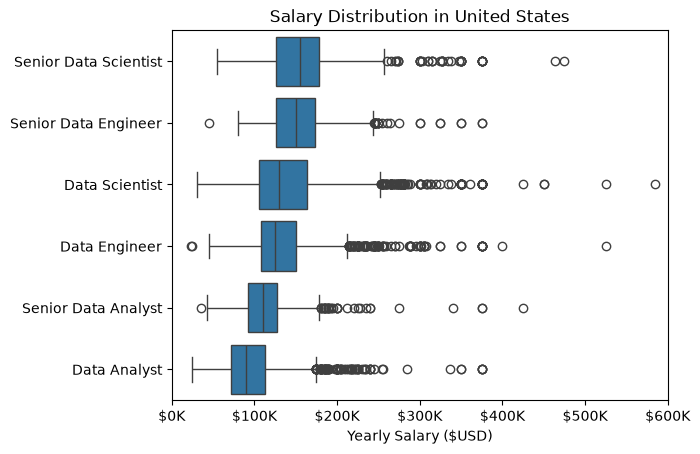

In [ ]:
df_US = df[(df['job_country'] == 'United States')].dropna(subset = ['salary_year_avg'])

job_titles = df_US['job_title_short'].value_counts().index[:6].to_list()

top_6 = df_US[df_US['job_title_short'].isin(job_titles)]

job_order   = top_6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending = False).index


sns.boxplot( data = top_6, x = 'salary_year_avg', y =  'job_title_short', order = job_order )
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.title('Salary Distribution in United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
plt.show()